# Exercise 5.1


In [14]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

**Simple Network**

We continue with the dataset first encountered in the previous exercise. Please refer to the discussion there for an introduction to the data and the learning objective.

Here, we manually implement a simple network architecture

In [15]:
# The code snippet below is responsible for downloading the dataset
# - for example when running via Google Colab.
#
# You can also directly download the file using the link if you work
# with a local setup (the !wget command will work either way assuming
# you are on a unix-based machine and have wget installed)
!wget -nc https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv

File ‘winequality-white.csv’ already there; not retrieving.



In [16]:


# Before working with the data,
# we download and prepare all features

# load all examples from the file
data = np.genfromtxt("winequality-white.csv", delimiter=";", skip_header=1)

print(f"{data.shape = }")

# Prepare for proper training
rng = np.random.default_rng(1234)
rng.shuffle(data)  # randomly sort examples

# take the first 3000 examples for training
# (remember array slicing from last week)
X_train = data[:3000, :11]  # all features except last column
y_train = data[:3000, 11]  # quality column

# and the remaining examples for testing
X_test = data[3000:, :11]  # all features except last column
y_test = data[3000:, 11]  # quality column

print("First example:")
print("Features:", X_train[0])
print("Quality:", y_train[0])

data.shape = (4898, 12)
First example:
Features: [6.8000e+00 1.9000e-01 7.1000e-01 1.7500e+01 4.2000e-02 2.1000e+01
 1.1400e+02 9.9784e-01 2.8500e+00 5.0000e-01 9.5000e+00]
Quality: 6.0


## Feature Standardization

When the loss curves are stagnant or stuck, it's preferable to standardize
 the input features for better model performance.
I have tried adjusting the hyperparameters before, but performance isn’t improving as desired.
So, this extra step can help standardize the data and enable the model to learn in a better way.
This usually happens when the input features have very different scales.

For example:

Feature ranges are,  
alcohol  8–14


sulphates  0–1


density  0.99–1.00

Without scaling, alcohol dominates numerically and the model gives it disproportionate influence.
Whereas after scaling, all features are comparable and weights become meaningful.

This preprocessing step ensures that all features contribute equally to the  calculations
and helps gradient descent converge more efficiently.
It will transform the data to have a mean of 0 and a standard deviation of 1.
In this way, the model learns all parameters in a similar way.


Otherwise, the training loss and test loss were both very high nearly 70   to 80 percent, which is bad. So, inspired from recent lecture on   preprocessing, we are making our data:   


*   centered around zero
*   same scale across all features




In [17]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)
print("First scaled training example:", X_train_scaled[0])

X_train_scaled shape: (3000, 11)
X_test_scaled shape: (1898, 11)
First scaled training example: [-0.06260036 -0.8790185   3.07923825  2.14845111 -0.17940754 -0.849691
 -0.55742249  1.24376342 -2.24084287  0.07359793 -0.80619348]


# Problems

The goal is to implement the training of a neural network with one input layer, one hidden layer, and one output layer using gradient descent. We first (below) define the matrices and initialise with random values. We need W, b, W' and b'. The shapes will be:
  * W: (number of hidden nodes, number of inputs) named `W`
  * b: (number of hidden nodes) named `b`
  * W': (number of hidden nodes) named `Wp`
  * b': (one) named `bp`

Your tasks are:     
   * Implement a forward pass of the network as `dnn` (see below)
   * Implement a function that uses one data point to update the weights using gradient descent. You can follow the `update_weights` skeleton below
   * Now you can use the code below (training loop and evaluation) to train the network for multiple data points and even over several epochs. Try to find a set of hyperparameters (number of nodes in the hidden layer, learning rate, number of training epochs) that gives stable results. What is the best result (as measured by the loss on the training sample) you can get?

In [18]:
# initialise weights after data scaling
# This ensures weights are appropriate for the new input scale.
# The number of hidden_nodes and n_inputs are
hidden_nodes = 100  # number of nodes in the hidden layer
n_inputs = 11  # input features in the dataset
W = rng.standard_normal(size=(hidden_nodes, n_inputs)) * np.sqrt(2.0 / n_inputs)
b = rng.standard_normal(size=hidden_nodes) * np.sqrt(2.0 / n_inputs)
Wp = rng.standard_normal(size=hidden_nodes) * np.sqrt(2.0 / hidden_nodes)
bp = rng.standard_normal(size=(1))



print(f"{W.shape = }")

W.shape = (100, 11)


In [19]:
# You can use this implementation of the ReLu activation function
def relu(x: np.ndarray) -> np.ndarray:
    """Simple implementation of a rectified linear unit.

    Parameters
    ----------
    x : array_like
        Array of input features.

    Returns
    -------
    np.ndarray
        Array containig function values of the relu for
        each element of the input array.
    """
    return np.maximum(x, 0)

In [20]:
def dnn(
    x: np.ndarray,
    W: np.ndarray,
    b: np.ndarray,
    Wp: np.ndarray,
    bp: np.ndarray,
) -> np.ndarray:
    """Simple DNN.

    Parameters
    ----------
    x : array_like
        Array of input features.
    W : array_like
        Array of input layer weights.
    b : array_like
        Array of input layer biases.
    Wp : array__like
        Array of output layer weighs.
    bp : array_like
        Array of output layer biases

    Returns
    -------
    np.ndarray, shape (1,)
        Array containing the float output of the DNN.
    """
    # using hint 1, Calculating firstly the input to hidden layer
    z = np.dot(W, x) + b
    # Apply ReLU activation
    a = relu(z)
    # Calculate output layer
    y_hat = np.dot(Wp, a) + bp
    return y_hat


In [21]:
def update_weights(
    x: np.ndarray,
    y: np.ndarray,
    W: np.ndarray,
    b: np.ndarray,
    Wp: np.ndarray,
    bp: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Updates weights for given inputs, targets,
    weights, and biases.

    Parameters
    ----------
    x : array_like
        Array of input features.
    y : array_like
        Array of target features.
    W : array_like
        Array of input layer weights.
    b : array_like
        Array of input layer biases.
    Wp : array__like
        Array of output layer weighs.
    bp : array_like
        Array of output layer biases

    Returns
    -------
    tuple
        Tuple of updated weight and bias arrays.
    """

    #learning_rate = 0.005  # TODO: choosing higher learning rate resulted
    #into constant training loss and exploded gradients
    #choosing 0.00007, that is, too low resulted into stuck gradients
    learning_rate = 0.0001  # tested various and in between learning rate
    # to prevent exploding gradients. its one of the hyperparameter of the
    #network

    # Calculate the network output (use the function dnn defined above)
    y_hat = dnn(x, W, b, Wp, bp)

    # Derive the gradient for each of W,b,Wp,bp by taking the partial
    # derivative of the loss function with respect to the variable and
    # then implement the resulting weight-update procedure
    # See Hint 2 for additional information

    # You might need these numpy functions:
    # np.dot, np.outer, np.heaviside
    # Hint: Use .shape and print statements to make sure all operations
    # do what you want them to

    # Error term (2 * (y_hat - y))
    dL_dy_hat = 2 * (y_hat - y)

    # Gradients for output layer
    grad_bp = dL_dy_hat

    # Calculate 'a' again for Wp gradient
    z = np.dot(W, x) + b
    a = relu(z)
    grad_Wp = dL_dy_hat * a

    # Gradients for hidden layer
    # Heaviside step function for ReLU derivative
    # np.heaviside(x, x2) returns 1 if x > 0, x2 if x == 0, and 0 if x < 0.
    # For derivative of ReLU, it's 1 if input > 0, 0 if input < 0, and can be 0 or 1 if input == 0.
    # Using 0 for when z == 0 is a common convention.
    theta_z = np.heaviside(z, 0)

    grad_b = dL_dy_hat * Wp * theta_z
    grad_W = np.outer(dL_dy_hat * Wp * theta_z, x)

    # Update the weights/bias following the rule:  weight_new = weight_old - learning_rate * gradient
    bp_new = bp - learning_rate * grad_bp
    Wp_new = Wp - learning_rate * grad_Wp
    b_new = b - learning_rate * grad_b
    W_new = W - learning_rate * grad_W

    return W_new, b_new, Wp_new, bp_new # return the new weights

# Training loop and evaluation below

In [22]:


# The code below implements the training.
# If you correctly implement  dnn and update_weights above,
# you should not need to change anything below.
# (apart from increasing the number of epochs)

train_losses = []
test_losses = []

# How many epochs to train
# This will just train for one epoch
# You will want a higher number once everything works
n_epochs = 100 #another hyperparameter, increasing it has improved the
#model performance. but dividing each epoch into minibatches could help
#even more

# Loop over the epochs
for ep in range(n_epochs):
    # Each epoch is a complete over the training data
    for i in range(X_train_scaled.shape[0]): # Use scaled training data
        # pick one example
        x = X_train_scaled[i]
        y = y_train[i]

        # use it to update the weights
        W, b, Wp, bp = update_weights(x, y, W, b, Wp, bp)

    # Calculate predictions for the full training and testing sample
    y_pred_train = [dnn(x, W, b, Wp, bp)[0] for x in X_train_scaled] # Use scaled training data
    y_pred = [dnn(x, W, b, Wp, bp)[0] for x in X_test_scaled] # Use scaled test data

    # Calculate aver loss / example over the epoch
    train_loss = np.sum((y_pred_train - y_train) ** 2) / y_train.shape[0]
    test_loss = np.sum((y_pred - y_test) ** 2) / y_test.shape[0]

    # print some information
    print("Epoch:", ep, "Train Loss:", train_loss, "Test Loss:", test_loss)

    # and store the losses for later use
    train_losses.append(train_loss)
    test_losses.append(test_loss)

Epoch: 0 Train Loss: 2.1468069614916834 Test Loss: 2.2463950104098145
Epoch: 1 Train Loss: 1.5523733377162043 Test Loss: 1.6567344819741152
Epoch: 2 Train Loss: 1.187589105205435 Test Loss: 1.2707588954030926
Epoch: 3 Train Loss: 0.9593826604733764 Test Loss: 1.025556919102039
Epoch: 4 Train Loss: 0.8167786476430289 Test Loss: 0.8687915183471008
Epoch: 5 Train Loss: 0.7275063235944185 Test Loss: 0.7696944802391624
Epoch: 6 Train Loss: 0.6712859885502281 Test Loss: 0.7069449146210399
Epoch: 7 Train Loss: 0.634630983722713 Test Loss: 0.6652662492062187
Epoch: 8 Train Loss: 0.6099719955912636 Test Loss: 0.6373007701932178
Epoch: 9 Train Loss: 0.5922992899288811 Test Loss: 0.6175368218734278
Epoch: 10 Train Loss: 0.5789900060060579 Test Loss: 0.6030219511602185
Epoch: 11 Train Loss: 0.569012434420943 Test Loss: 0.5922774762104089
Epoch: 12 Train Loss: 0.5611403155335678 Test Loss: 0.5838403338064749
Epoch: 13 Train Loss: 0.5545449776397969 Test Loss: 0.5769422004859341
Epoch: 14 Train Loss

Best loss: 0.5030661528094558 Final loss: 0.5030661528094558
Correlation coefficient: -0.21294796094071272


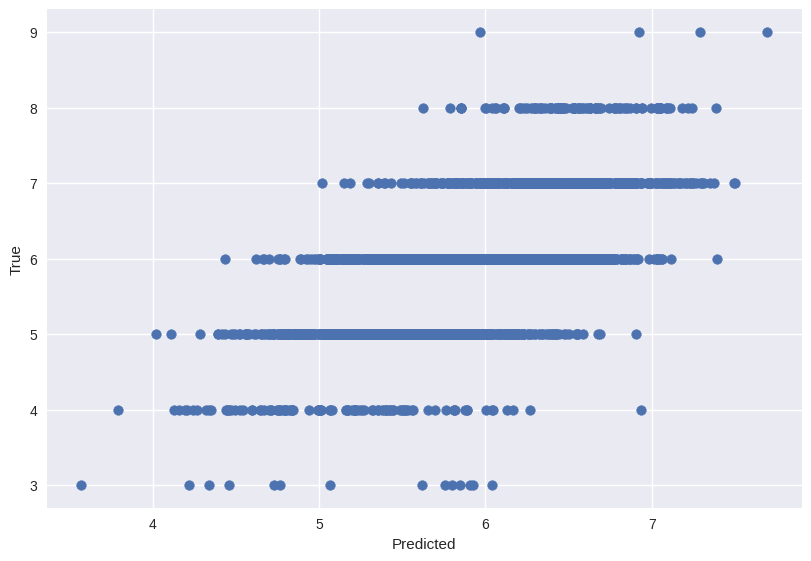

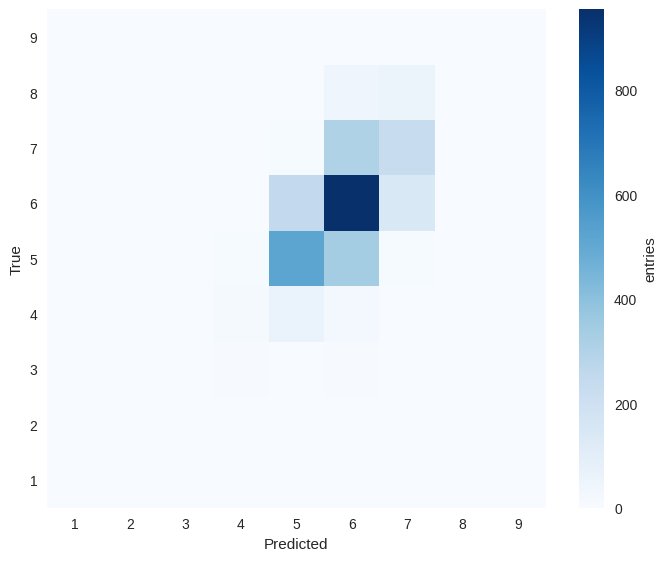

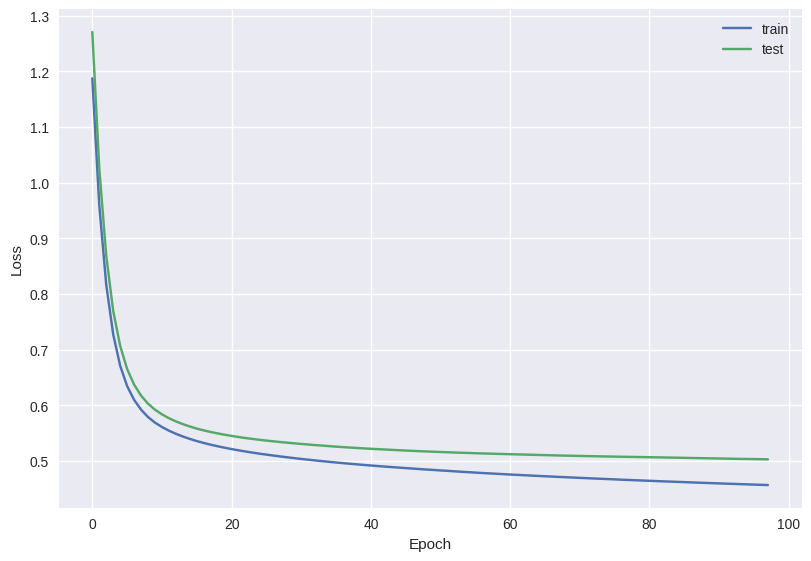

In [23]:
# After the training:

# Prepare scatter plot
y_pred = [dnn(x, W, b, Wp, bp)[0] for x in X_test]

print("Best loss:", min(test_losses), "Final loss:", test_losses[-1])

print("Correlation coefficient:", np.corrcoef(y_pred, y_test)[0, 1])
fig, ax = plt.subplots(layout="constrained")
ax.scatter(y_pred_train, y_train)

ax.set(
    xlabel="Predicted",
    ylabel="True",
)

fig, ax = plt.subplots(layout="constrained")
h = ax.hist2d(
    y_pred_train,
    y_train,
    bins=[np.arange(0.5, 10.5, 1), np.arange(0.5, 10.5, 1)],
    cmap="Blues",
)

ax.set(
    xlabel="Predicted",
    ylabel="True",
    aspect="equal",
)

cbar = fig.colorbar(h[3], ax=ax)
cbar.set_label("entries")


# Prepare and loss over time
fig, ax = plt.subplots(layout="constrained")
ax.plot(train_losses[2:], label="train")
ax.plot(
    test_losses[2:], label="test"
)  # we omit the first data points as the first loss is typically very high which makes it difficult to read the plot.
ax.legend()
ax.set(
    xlabel="Epoch",
    ylabel="Loss",
);

# Comments
The figure shows that training and test loss decreases and also the trend is similar for both of them, with a very faint correlation of -0.2129. however for a ideal regression training, we expect a strong positive correklation between predicted and true wine quality.
Clearly current model doesnt show any signs of underfitting or overfitting. but 50% isnt a good loss either. The model is performin just meh.

The model performance has been improved, firstly by standarising the features. Secondly by tuning appropriate values for learning rate. As too high value like 0.005 resulted into exploding gradients and freeyed out trauining loss and no improvements in perfromance. However setting it too low like 0.00007 also stuck the gradients and performance didnt improve as much throughout the gradients steps. Hence a moderate value was found 0.0001, which worked fine.


Moreover increasing the number of hidden nodes also improves the performance as the network has more paarmeters to captures the details and learn better. Otherwise the model is too simple to capture the details.

Increasing the number of epochs also improves performance, as model goes through data again and again and more updates and imporvements after each epoch. The effect after each epoch can be seen on the training and test loss.  


Next approach toi improve the model could inco´rporate creating mini batch training. Currently our model updates weights after each single data point. Grouping various data points into mini batches for each update can often lead to stable and efficient learning. Moreover, increasing number of hidden layer i.e deepening the network also improves the perfromance, with hjigher resolution for the data, and better predictions resultantly.

# Hint 1

We want a network with one hidden layer. As activiation in the hidden layer $\sigma$ we apply element-wise ReLu, while no activation is used for the output layer. The forward pass of the network then reads:
$$\hat{y}=\mathbf{W}^{\prime} \sigma(\mathbf{W} \vec{x}+\vec{b})+b^{\prime}$$

# Hint 2

For the regression problem the objective function is the mean squared error between the prediction and the true label $y$:
$$
L=(\hat{y}-y)^{2}
$$

Taking the partial derivatives - and diligently the applying chain rule - with respect to the different objects yields:

$$
\begin{aligned}
\frac{\partial L}{\partial b^{\prime}} &=2(\hat{y}-y) \\
\frac{\partial L}{\partial b_{k}} &=2(\hat{y}-y) \mathbf{W}_{k}^{\prime} \theta\left(\sum_{i} \mathbf{W}_{k i} x_{i}+b_{k}\right) \\
\frac{\partial L}{\partial \mathbf{W}_{k}^{\prime}} &=2(\hat{y}-y) \sigma\left(\sum_{i} \mathbf{W}_{k i} x_{i}+b_{k}\right) \\
\frac{\partial L}{\partial \mathbf{W}_{m k}} &=2(\hat{y}-y) \mathbf{W}_{m}^{\prime} \theta\left(\sum_{i} \mathbf{W}_{m i} x_{i}+b_{m}\right) x_{k}
\end{aligned}
$$

Here, $\Theta$ denotes the Heaviside step function.